# **Triage Copilot Model**
by Marcos Salazar



**Purpose:**

This notebook trains a machine learning pipeline (TF-IDF + LinearSVC) to classify bilingual student inquiries into 6 administrative categories (Admissions, Advising, Financial Services, ESL, Navigate, Appointment).

**Expected Outcomes:**

The trained Scikit-learn pipeline for the FastAPI backend. (model.joblib)

AND

The cleaned reference dataset for the learning feedback loop. (training_data.csv)

Installing Scikit-learn.

In [143]:
!pip install -U scikit-learn

Importing the library and verifying library version.

In [144]:
import sklearn

print(sklearn.__version__)

1.9.0


**Setup:**

Importing necessary libraries.

In [145]:
#Data Manipulation
import pandas as pd
import numpy as np
import random

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

#Export tools
import joblib

#Reproducibility
random.seed(42)
np.random.seed(42)

Loading data from (training_phrases.csv)

In [146]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [147]:
phrases_df = pd.read_csv('/content/drive/MyDrive/Triage-Copilot-Folder/training_phrases.csv')
print(phrases_df.shape)
phrases_df.head()

(100, 4)


,Category,Subcategory,Language,Phrase
0,Admissions / Enrollment,Application Assistance,EN,I need help with my application
1,Admissions / Enrollment,Application Assistance,EN,Can someone help me finish applying
2,Admissions / Enrollment,Application Assistance,EN,I'm stuck on the admissions application
3,Admissions / Enrollment,Application Assistance,ES,Necesito ayuda con mi aplicación
4,Admissions / Enrollment,Application Assistance,ES,¿Alguien me puede ayudar a terminar de aplicar?


/tmp/ipykernel_543/1078633369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=phrases_df, x="Category", order=phrases_df["Category"].value_counts().index, palette="viridis")


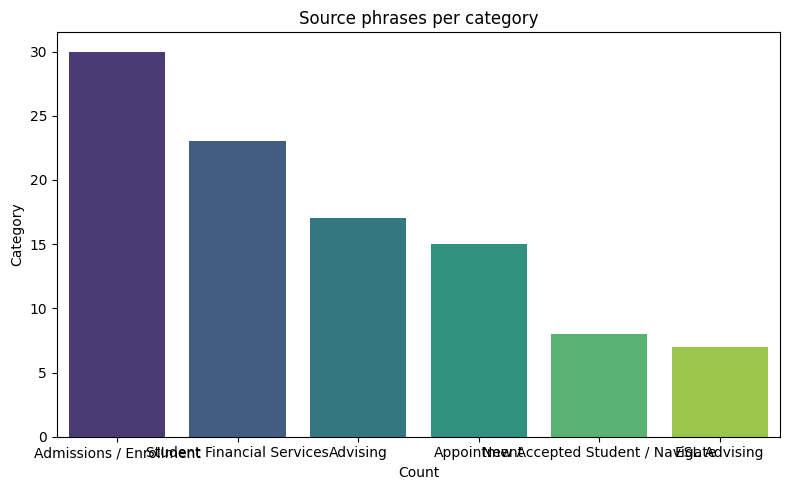

In [148]:
plt.figure(figsize=(8, 5))
sns.countplot(data=phrases_df, x="Category", order=phrases_df["Category"].value_counts().index, palette="viridis")
plt.title("Source phrases per category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [149]:
print("Source phrase count by category:")
print(phrases_df["Category"].value_counts())

print("\nSource phrase count by subcategory:")
print(phrases_df["Subcategory"].value_counts())

print("\nMissing values check:")
print(phrases_df.isnull().sum())

phrases_df["phrase_length"] = phrases_df["Phrase"].apply(len)
print("\nAvg phrase length by category:")
print(phrases_df.groupby("Category")["phrase_length"].mean().sort_values())

Source phrase count by category:
Category
Admissions / Enrollment            30
Student Financial Services         23
Advising                           17
Appointment                        15
New Accepted Student / Navigate     8
ESL Advising                        7
Name: count, dtype: int64

Source phrase count by subcategory:
Subcategory
Application Assistance                    5
Copy of Transcript                        5
I need an N#                              5
Course Registration                       5
Placement Questions                       5
ESL Advising and Registration             4
Billing, Payments and Refunds             4
International Student Inquiry             3
Verification Letter                       3
Change of Program                         3
Course Withdrawal                         3
Non-credit Registration                   3
Guest Student Course Registration         3
Enrollment Form Completion                3
Admissions/Enrollment Appointment      

Using the same training data, I will generate more training data from the loaded phrases by creating minor variations.

# **SUPERSEEDED!**
See leakage analysis below

In [150]:
# # Function that generates variants of the pre-existing data

# def augment_phrase(phrase):
#   variants = [phrase, phrase.lower(), phrase + "?", phrase + "."]
#   return random.choice(variants)

# #Generative goal of 60 examples per department (combat overfitting)
# TARGET_PER_CATEGORY = 60

# rows = []

# for category in phrases_df["Category"].unique():
#   category_rows = phrases_df[phrases_df["Category"] == category]

#   #Counter - Artificial samples created for current category.
#   generated = 0

#   while generated < TARGET_PER_CATEGORY:

#     sample = category_rows.sample(1).iloc[0]
#     phrase = augment_phrase(sample["Phrase"])
#     rows.append({
#         "text": phrase,
#         "category": sample["Category"],
#         "subcategory": sample["Subcategory"]
#     })
#     generated += 1

# #Create new dataframe for Artificial samples/training data.
# newData = pd.DataFrame(rows).drop_duplicates(subset="text").reset_index(drop=True)
# newData.to_csv("training_data.csv", index=False)

In [151]:
def augment_phrase(phrase):
    variants = [phrase, phrase.lower(), phrase + "?", phrase + "."]
    return random.choice(variants)

**Fix: split source phrases before augmenting**

In [152]:
# Split SOURCE phrases first, before augmenting — this is the fix for the leakage bug (variants of the same phrase can no longer land on both sides)
train_phrases_df, test_phrases_df = train_test_split(
    phrases_df, test_size=0.2, random_state=42, stratify=phrases_df["Category"]
)

# generates augmented examples from a given set of source phrases
def generate_examples(source_df, target_per_category):
    rows = []
    for category in source_df["Category"].unique():
        category_rows = source_df[source_df["Category"] == category]

        #Counter - Artificial samples created for current category.
        generated = 0

        while generated < target_per_category:
            sample = category_rows.sample(1).iloc[0]
            phrase = augment_phrase(sample["Phrase"])
            rows.append({
                "text": phrase,
                "category": sample["Category"],
                "subcategory": sample["Subcategory"]
            })

            generated += 1
    return pd.DataFrame(rows).drop_duplicates(subset="text").reset_index(drop=True)

trainData = generate_examples(train_phrases_df, target_per_category=60)
testData = generate_examples(test_phrases_df, target_per_category=15)

trainData.to_csv("training_data.csv", index=False)

Let's analyze the new data.

In [153]:
print(trainData.shape)
trainData.head(10)


(200, 3)


,text,category,subcategory
0,I need to register for ESL classes,ESL Advising,ESL Advising and Registration
1,I want to talk to someone about English langua...,ESL Advising,ESL Advising and Registration
2,Necesito registrarme en clases de inglés?,ESL Advising,ESL Advising and Registration
3,i need to register for esl classes,ESL Advising,ESL Advising and Registration
4,what level esl class am i supposed to take,ESL Advising,Placement Questions
5,i have a question about my esl placement test,ESL Advising,Placement Questions
6,I need to register for ESL classes.,ESL Advising,ESL Advising and Registration
7,Quiero hablar sobre cursos de ESL,ESL Advising,ESL Advising and Registration
8,I have a question about my ESL placement test,ESL Advising,Placement Questions
9,i want to talk to someone about english langua...,ESL Advising,ESL Advising and Registration


Taking a look at the data and confirm that there are no missing values.

In [154]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         200 non-null    object
 1   category     200 non-null    object
 2   subcategory  200 non-null    object
dtypes: object(3)
memory usage: 4.8+ KB


In [155]:
trainData.describe()

,text,category,subcategory
count,200,200,200
unique,200,6,30
top,I need to register for ESL classes,Admissions / Enrollment,ESL Advising and Registration
freq,1,47,15


Train/Test split

In [156]:
X_train = trainData["text"]
y_train = trainData["category"]
X_test = testData["text"]
y_test = testData["category"]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(y_train.value_counts())

Train size: 200, Test size: 49
category
Admissions / Enrollment            47
Student Financial Services         41
Advising                           39
Appointment                        31
ESL Advising                       21
New Accepted Student / Navigate    21
Name: count, dtype: int64


Note: **Model will predict Category, will upscale to Sub-Category as well later into development**

Building the pipeline.

In [157]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,
        lowercase=True
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

ngram_range=(1, 2) chosen due to two-word pairs carrying more meaning than an individual word can capture.

In [158]:
print(pipeline)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


Fitting the pipeline.

In [159]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Accuracy check.

In [160]:
train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Gap: {train_accuracy - test_accuracy:.3f}")

Train Accuracy: 0.985
Test Accuracy: 0.449
Gap: 0.536


FIXED* OLD Results: LEAKAGE

Train Accuracy 1.000, Test Accuracy 1.000, Gap 0.000


Analysis: Perfect score on both sets isn't strong evidence of generalization, I presume the test isn't hard enough yet. augment_phrase() is generating near duplicate variants before the train/test split.

Conclusion/Next Step:

Group by source phrase before splitting, so variants of the same phrase cant land on both sides.

NEW* Results:


Train Accuracy 0.985, Test Accuracy 0.449, Gap 0.536


**Leakage check below:** 0/49 confirmed clean no near duplicates.

**Analysis:** With leakage removed, the real overfitting gap is now visible.

Likely cause: augmentation only varies casing/punctuation, not real diversity in terms of phrasing, with few unique source phrases per subcategory.

**Result:** This confirms the need for LLM generated training data, not only to reach a minimum of 1500 phrases, but specifically add genune diversity per subcategory.

In [161]:
# checking to see if near duplicate vari. are leaking across the train/test
from difflib import SequenceMatcher

leaks = 0
for test_phrase in X_test:
    for train_phrase in X_train:
        similarity = SequenceMatcher(None, test_phrase.lower(), train_phrase.lower()).ratio()
        if similarity > 0.9:
            leaks += 1
            break
print(f"Test phrases with a near-duplicate in train: {leaks} / {len(X_test)}")

Test phrases with a near-duplicate in train: 0 / 49


FIXED* OLD LEAKGE RESULTS: 42 out of 46 test phrases have near duplicates sitting in train. Model was essentially being tested on data it has already seen.